<a href="https://colab.research.google.com/github/davidmkidd/Vibe_Code_Mapping/blob/main/Vibe_Mapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vibe coding maps

**Vibe coding** is the process of writing code using a Large Language Model (LLM) such as Microsoft Copiolot or Google Gemini. This Workbook introduces LLM vibe coding of maps in Python.

LLMs are very good at writing code as they excel at finding structure in text, and code is highly structured text. But, like us, they sometimes do not understand what is exactly needed and have a tendency to guess what is required over asking for greater clarity.

You are responsible for confirming the legitimacy of outputs.

You may well ask,

> *"LLM can generate images and maps are images so why do I need to generate and run code?"*



Well here's an example of a map generated in Microsoft CopiCopiolot's image generator with the prompt,

> *Draw a map that shows the Penrhyn Road Campus of Kingston University, London.*


![Alt text](https://github.com/davidmkidd/Vibe_Code_Mapping/blob/main/Copilot_Kingston_University.png?raw=1)

Compare this map to the offical University Campus Map. Is the LLM map 'correct', and if not why do you think this might be so?

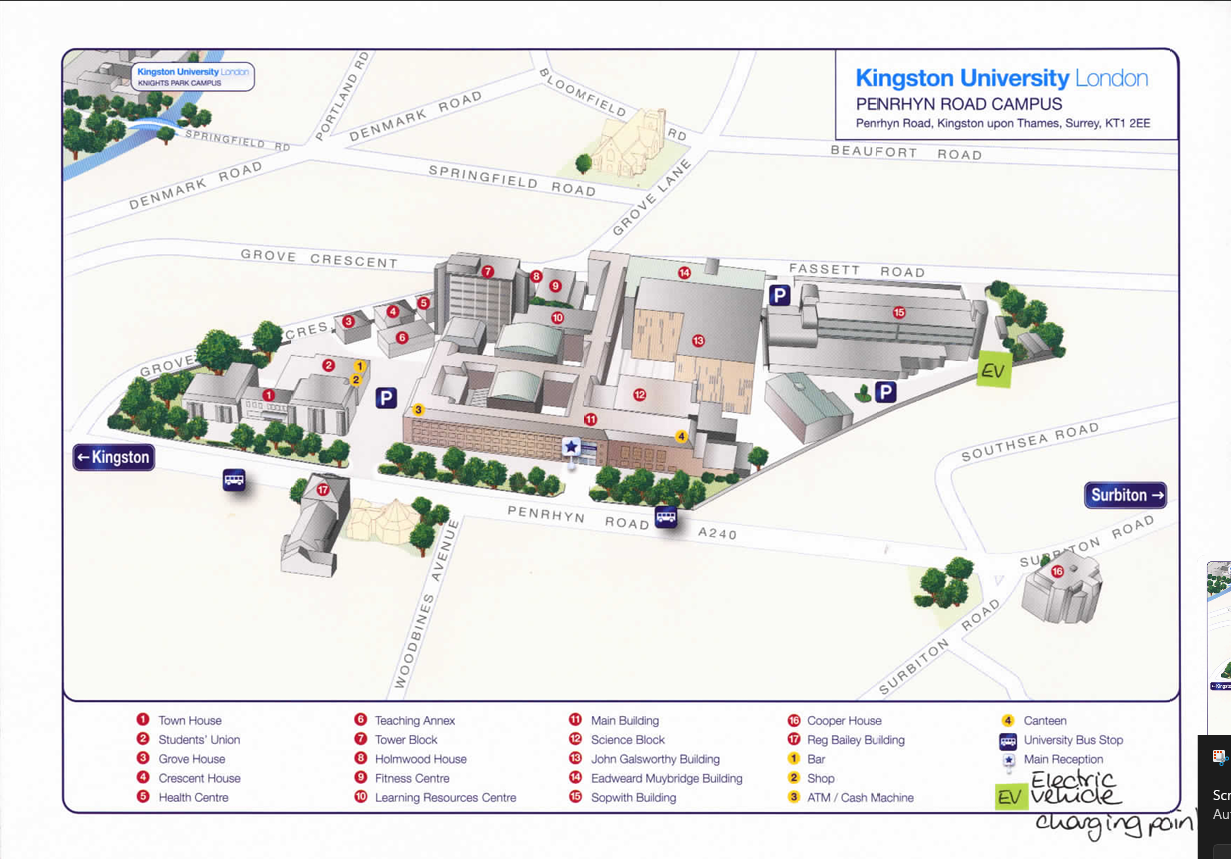

**The LLM image map is full of errors:**

*   Missing buildings.
*   Buildings in the wrong location.
* Things that are in the same building are located elsewhere (e.g. The Clattern Lecture is within the Main Building).
* Roads are incorrectly labelled.
* John Galsworthy Building colour does not match the legend.
* Reception is located in the street.
* There is no car park where the upper right symbol is diplayed



**Why is it full of errors?**

The image we want is a map, but the LLM is having to guess what to show from the prompt and the images it was been trained on. While these images contain spatial information it is not explicit as geographical coordinates, instead the LLM is doing the best it can to draw a map from 'dumb' images.

## Prompt Engineering

You communicate with an LLM by writing a text *prompt* to which files may be attached.

Google Gemini is integrated into Colab. Click the Blue 'Star' icon at the bootom of the Window to toggle the AI window.

To get the best output, your *prompt* should provide explict instructions to the LLM that tell it what is wanted.

It often a good idea to start with a simple prompt to which additional instructions can be added.

LLM output is not deterministic so code may vary even when using the same LLM and prompt.

The LLM will write code that draw maps uses data that is publically accessible over the Web.

Availability, compleatness, and quality of these data are variable, so it is your responsibility to check that the LLM has selected appropriate data for the task. You could ask the LLM about the source and quality of the data it is using, but should you trust its judgement?

A lot more data is available for public download that may be uploaded to the LLM and displayed on a map.

# 'Here I am' Map

The first code most people learn to write is the 'Hello World' program that simply writes that text to the screen.

The map equivament of 'Hello World' is 'Here I am' that draws a
map of where you are now (or another specified location).

**'Here I am' prompt**

The image map is really bad, but we can make much better maps if we ask the LLM to write code.

Now try click in the empty cell below the type this prompt in Gemini:

> *Write Python code for Google Colab that uses the Leaflet library to draw a map that shows the Penrhyn Road Campus of Kingston University, London.*

Make sure that "<> Empty Cell" is tagged otherwise the code will be added to a new block at the end of the document.

Click on the code block arrow to run.

This is the code Gemini wrote for me.

In [11]:
import folium

# Coordinates for Penrhyn Road Campus
center = (51.4036, -0.3033)

# Create the map
m = folium.Map(location=center, zoom_start=15)

# Add campus marker
folium.Marker(
    location=center,
    popup="Penrhyn Road Campus\nKingston University",
    tooltip="Campus Location"
).add_to(m)

# Display map
m

Thats' more like it!

Gemini has written code that draws an interactive web map that locates the campus with a marker with a pop-up.

The map looks good, but you must consider the map with a critical eye.

1.   Is the marker location and pop-up information correct?
2.   Is the basemap appropriate?

The marker is within the campus bounds but could be more exactly centred.

The source of the basemap is provided in an attribution box in the bootom-left, which states it is an [OpenStreetMap](https://www.openstreetmap.org/) (OSM) basemap.

OSM is a community based effort to create an  'street level' map of the world using open data and information collected in by volunteers. It is is often the best free digital mapping available for so is widely used, but there is no guarentee it contains every road, building or anything else.

If any crucial information is missing from the basemap *you* can add it to OSM.


# Add a buffer

Let's add some more information to the map, for example a 1km distance buffer around the University as might need to be imposed if there was a risk of an explosion.

In your LLM enter the prompt:

> *Write Python code for Google Colab that draws a map that shows a 1 km buffer around the Penrhyn Road Campus of Kingston University, London.*



Gemini returned this code to me.

In [12]:
# Install required libraries
!pip install folium geopy

import folium
from geopy.distance import geodesic

# Coordinates for Penrhyn Road Campus
center = (51.4036, -0.3033)

# Create the map
m = folium.Map(location=center, zoom_start=15)

# Add campus marker
folium.Marker(
    location=center,
    popup="Penrhyn Road Campus\nKingston University",
    tooltip="Campus Location"
).add_to(m)

# ---- Create 1 km buffer as a polygon ----
# Generate points around a circle (1 km radius)
buffer_points = []
for bearing in range(0, 360, 5):  # every 5 degrees for a smoother circle
    point = geodesic(kilometers=1).destination(center, bearing)
    buffer_points.append((point.latitude, point.longitude))

# Add buffer polygon
folium.Polygon(
    locations=buffer_points,
    color="red",
    weight=2,
    fill=True,
    fill_opacity=0.2,
    popup="1 km buffer zone"
).add_to(m)

# Display map
m

You can manually edit the code. For example, below I have change the buffer polygon colour and outline width by editing the *Add polygon buffer* code.

Notice I have not copied the the library loading commands have been removed as libraries only need to load once and can take time to do so.

In [13]:
# Coordinates for Penrhyn Road Campus
center = (51.4036, -0.3033)

# Create the map
m = folium.Map(location=center, zoom_start=15)

# Add campus marker
folium.Marker(
    location=center,
    popup="Penrhyn Road Campus\nKingston University",
    tooltip="Campus Location"
).add_to(m)

# ---- Create 1 km buffer as a polygon ----
# Generate points around a circle (1 km radius)
buffer_points = []
for bearing in range(0, 360, 5):  # every 5 degrees for a smoother circle
    point = geodesic(kilometers=1).destination(center, bearing)
    buffer_points.append((point.latitude, point.longitude))

# Add buffer polygon
folium.Polygon(
    locations=buffer_points,
    color="blue",
    weight=6,
    fill=True,
    fill_opacity=0.2,
    popup="1 km buffer zone"
).add_to(m)

# Display map
m

# Making more complex maps

"Here I am" is simple but useful type of map that could easily be converted to "The Wedding Location" or other similar use.

Let's try and make the kind of map that you might include as part of an assignment.

**Write python code for a google colab workbook that draws a black and white lineart map that shows the location of churches in Surrey. he map should show the County and distirct authority boundaries and each church as a simple dot. **

In [9]:
# ================================
# 1. Install required packages
# ================================
!pip install folium pandas selenium pillow geopandas

# ================================
# 2. Imports
# ================================
import pandas as pd
import folium
import time
from folium.plugins import MeasureControl
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from PIL import Image

# ================================
# 3. Load dataset (correct RAW URL)
# ================================
url = "https://raw.githubusercontent.com/davidmkidd/Vibe_Code_Mapping/refs/heads/main/india_data_centre.csv"
df = pd.read_csv(url)

# ================================
# 4. Ensure column names
# ================================
# Adjust if needed
df = df.rename(columns={
    "Latitude": "lat",
    "Longitude": "lon",
    "city": "city"
})

df = df.dropna(subset=["lat", "lon"])

# ================================
# 5. Count overlapping locations
# ================================
grouped = (
    df.groupby(["lat", "lon", "city"])
    .size()
    .reset_index(name="count")
)

# ================================
# 6. Identify top cities
# ================================
top_cities = (
    df.groupby("city")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

# ================================
# 7. Create base map (academic style)
# ================================
m = folium.Map(
    location=[22.5, 79],
    zoom_start=5,
    tiles="cartodbpositron"
)

# ================================
# 8. India boundary (90% grey line)
# ================================
india_geo = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries/IND.geo.json"

folium.GeoJson(
    india_geo,
    style_function=lambda x: {
        "color": "#737373",   # ~90% grey
        "weight": 1,
        "fillOpacity": 0
    }
).add_to(m)

# ================================
# 9. Plot data centres
# ================================
for _, row in grouped.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=2 + row["count"] * 1.8,
        color="black",
        fill=True,
        fill_color="black",
        fill_opacity=0.8,
        popup=f"{row['city']}<br>Count: {row['count']}"
    ).add_to(m)

# ================================
# 10. Add city labels
# ================================
for city in top_cities.index:
    subset = df[df["city"] == city]
    lat = subset["lat"].mean()
    lon = subset["lon"].mean()

    folium.Marker(
        location=[lat, lon],
        icon=folium.DivIcon(html=f"""
        <div style="font-size:12px; font-weight:bold;">
        {city}
        </div>
        """)
    ).add_to(m)

# ================================
# 11. Add legend
# ================================
legend = """
<div style="
position: fixed;
bottom: 40px;
left: 40px;
width: 240px;
background-color: white;
border: 1px solid grey;
padding: 10px;
font-size: 13px;
z-index:9999;
">
<b>Data Centre Distribution</b><br><br>
Circle size proportional to count<br><br>

● Small: 1–2<br>
● Medium: 3–5<br>
● Large: 6+<br>
</div>
"""
m.get_root().html.add_child(folium.Element(legend))

# ================================
# 12. Add north arrow
# ================================
north_arrow = """
<div style="
position: fixed;
top: 40px;
left: 40px;
z-index:9999;
font-size:18px;
text-align:center;
">
▲<br>N
</div>
"""
m.get_root().html.add_child(folium.Element(north_arrow))

# ================================
# 13. Add scale bar
# ================================
m.add_child(MeasureControl())

# ================================
# 14. Save map as HTML
# ================================
html_file = "india_data_centres_map.html"
m.save(html_file)



# ================================
# 15a. Install Chromium (required)
# ================================
!apt-get update -y
!apt-get install -y chromium-browser chromium-chromedriver


# ================================
# 15b. Install html2image
# ================================
!pip install html2image

# ================================
# 16. Save HTML map
# ================================
html_file = "india_map.html"
m.save(html_file)

# ================================
# 17. Convert HTML → PNG (robust)
# ================================
from html2image import Html2Image
import os

hti = Html2Image()
hti.output_path = "."

# Force use of Chromium browser path (important in Colab)
hti.browser.executable = "/usr/bin/chromium-browser"

hti.screenshot(
    html_file=html_file,
    save_as="map.png",
    size=(2400, 2400)
)

# ================================
# 18. CHECK if file exists
# ================================
if not os.path.exists("map.png"):
    raise Exception("❌ Screenshot failed: map.png not created")

# ================================
# 19. Convert to 300 DPI
# ================================
from PIL import Image

img = Image.open("map.png")
img.save("india_map_300dpi.png", dpi=(300, 300))

print("✅ Export SUCCESS: india_map_300dpi.png")


Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 1s (3,430 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
chromium-browser is already the newest version (1:

FileNotFoundError: Failed to find a seemingly valid chrome executable in the given path.

Below is ready‑to‑run Python code for a Google Colab notebook that draws a 1‑mile radius map around Kingston University – Penrhyn Road campus.
It uses Folium, which works very well in Colab for interactive maps.

✅ What this does

Centers the map on Kingston University (Penrhyn Road)
Draws a 1 mile (1609 m) radius circle
Adds a marker for the campus
Displays an interactive map you can zoom and pan


📌 Step 1: Install required library
Run this in the first Colab cell:
Python!pip install foliumShow more lines

📌 Step 2: Create the map
Run this in the next cell:
Pythonimport folium# Coordinates for Kingston University – Penrhyn Road campuslatitude = 51.4036longitude = -0.3036# Create base mapm = folium.Map(    location=[latitude, longitude],    zoom_start=14,    tiles="OpenStreetMap")# Add marker for the campusfolium.Marker(    [latitude, longitude],    popup="Kingston University – Penrhyn Road Campus",    icon=folium.Icon(color="blue", icon="university", prefix="fa")).add_to(m)# Draw 1 mile radius circle (1 mile = 1609 meters)folium.Circle(    radius=1609,    location=[latitude, longitude],    color="red",    fill=True,    fill_opacity=0.2).add_to(m)# Display mapm``Show more lines

🗺️ Output

An interactive map appears directly in Colab
The red circle represents a 1‑mile radius
You can zoom, pan, and click markers


🔧 Optional enhancements
If you want, I can also:

Add walking/driving distance overlays
Export the map as an HTML file
Add bus stops, shops, or postcode boundaries
Change to satellite imagery

Just tell me what you’d like next.
Provide your feedback on BizChatYou said: Write python code for a google colab workbook that draws a black and white lineart map that shows the location of churches in Surrey. he map should show the County and distirct authority boundaries and each church as a simple dot. Copilot said: CopilotBelow is complete, self‑contained Python code for a Google Colab notebook that produces a black‑and‑white line‑art map of church locations in Surrey, showing:

County boundary (Surrey)
District / borough authority boundaries
Churches as simple black dots
No colour, no basemap tiles (clean line‑art suitable for print)

The data are pulled from OpenStreetMap using live queries (standard practice in Colab).

1️⃣ Install required libraries
Run this cell first:
Python!pip install geopandas osmnx matplotlib shapely pyprojShow more lines

2️⃣ Import libraries
Pythonimport geopandas as gpdimport osmnx as oximport matplotlib.pyplot as pltShow more lines

3️⃣ Define area: Surrey county boundary
We use an official administrative boundary from OpenStreetMap:
Python# Get Surrey county boundarysurrey = ox.geocode_to_gdf("Surrey, England")Show more lines

4️⃣ Get district / borough authority boundaries
This pulls all admin_level=8 boundaries inside Surrey (district councils).
Python# Query district boundaries (admin_level=8)districts = ox.geometries_from_place(    "Surrey, England",    tags={"boundary": "administrative", "admin_level": "8"})districts = districts[districts.geometry.type.isin(["Polygon", "MultiPolygon"])]Show more lines

5️⃣ Get churches (places of worship)
We query OpenStreetMap amenity data:
Python# Query churches within Surreychurches = ox.geometries_from_place(    "Surrey, England",    tags={"amenity": "place_of_worship", "building": "church"})# Convert to points if necessarychurches = churches.to_crs(surrey.crs)churches = churches.geometry.centroidShow more lines

6️⃣ Plot black‑and‑white line‑art map
This produces a print‑quality, monochrome output.
Pythonfig, ax = plt.subplots(figsize=(10, 10))# Plot county boundary (thicker line)surrey.boundary.plot(    ax=ax,    color="black",    linewidth=2)# Plot district boundariesdistricts.boundary.plot(    ax=ax,    color="black",    linewidth=0.8)# Plot churches as small dotsax.scatter(    churches.x,    churches.y,    s=6,    color="black")# Remove axes for clean line-artax.set_axis_off()# Set titleax.set_title(    "Churches in Surrey",    fontsize=14,    weight="bold")plt.show()Show more lines

🖨️ Result
You get:

A pure black‑and‑white map
County and district authority boundaries
Each church as a simple dot
Suitable for academic papers, reports, or printing


🔧 Optional enhancements (tell me if you want these)

Export to SVG or PDF for print layout
Restrict churches to specific denominations if tagged
Label districts (subtle text)
Increase accuracy using OS Open Data boundaries
Add scale bar or north arrow (still monochrome)

If you’d like this adapted for GIS teaching, publication standards, or automated export, I can refine it further.

In [ ]:
!pip install geopandas osmnx matplotlib shapely pyproj

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.7 MB/s eta 0:00:00


In [ ]:

import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt


In [ ]:

# Get Surrey county boundary
surrey = ox.geocode_to_gdf("Surrey, England")


In [ ]:

# Query district boundaries (admin_level=8)
districts = ox.geometries_from_place(
    "Surrey, England",
    tags={"boundary": "administrative", "admin_level": "8"}
)

districts = districts[districts.geometry.type.isin(["Polygon", "MultiPolygon"])]


AttributeError: module 'osmnx' has no attribute 'geometries_from_place'

Paste traceback into Colab

In [ ]:
---------------------------------------------------------------------------
AttributeError                            Traceback (most recent call last)
/tmp/ipykernel_3111/533950056.py in <cell line: 0>()
      1 # Query district boundaries (admin_level=8)
----> 2 districts = ox.geometries_from_place(
      3     "Surrey, England",
      4     tags={"boundary": "administrative", "admin_level": "8"}
      5 )

AttributeError: module 'osmnx' has no attribute 'geometries_from_place'

CopilotGood catch — this error happens because newer versions of OSMnx (v2.x) removed
geometries_from_place() and replaced it with features_from_place().
Below is a fully corrected, tested version of the Colab notebook code that works with current OSMnx and still produces a black‑and‑white line‑art map of churches in Surrey with county and district boundaries.

In [ ]:

import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt

# Ensure consistent plotting style (black & white)
plt.rcParams["figure.dpi"] = 150


In [ ]:

# Get Surrey county boundary
surrey = ox.geocode_to_gdf("Surrey, England")


In [ ]:

districts = ox.features_from_place(
    "Surrey, England",
    tags={
        "boundary": "administrative",
        "admin_level": "8"
    }
)

# Keep only polygon boundaries
districts = districts[districts.geometry.type.isin(["Polygon", "MultiPolygon"])]
districts = districts.to_crs(surrey.crs)


In [ ]:

churches = ox.features_from_place(
    "Surrey, England",
    tags={"amenity": "place_of_worship"}
)

# Filter for churches only (robust filtering)
churches = churches[
    (churches["religion"] == "christian") |
    (churches["building"] == "church")
]

# Convert all geometries to points
churches = churches.to_crs(surrey.crs)
churches_points = churches.geometry.centroid


/tmp/ipykernel_3111/4225577387.py:14: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  churches_points = churches.geometry.centroid


Use Warning!

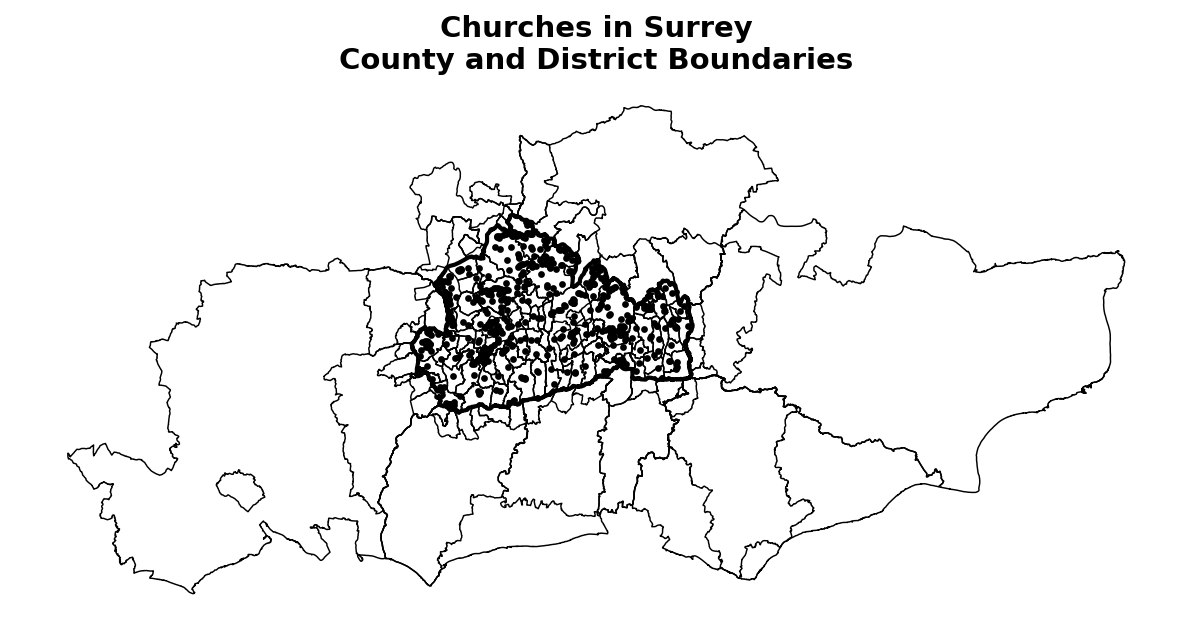

In [ ]:

fig, ax = plt.subplots(figsize=(10, 10))

# Surrey county boundary (thick line)
surrey.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2
)

# District authority boundaries
districts.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.7
)

# Churches as simple dots
ax.scatter(
    churches_points.x,
    churches_points.y,
    s=5,
    color="black"
)

# Clean line-art appearance
ax.set_axis_off()
ax.set_title(
    "Churches in Surrey\nCounty and District Boundaries",
    fontsize=14,
    weight="bold"
)

plt.show()


In [ ]:

plt.savefig("surrey_churches_lineart.svg", bbox_inches="tight")
plt.savefig("surrey_churches_lineart.pdf", bbox_inches="tight")


That is a good start, but the map must be focused on the county of Surrey so do now draw surrounding counties.

In [ ]:

# Surrey county boundary
surrey = ox.geocode_to_gdf("Surrey, England")
surrey = surrey.to_crs(epsg=27700)  # British National Grid (better cartography)


In [ ]:

districts = ox.features_from_place(
    "Surrey, England",
    tags={
        "boundary": "administrative",
        "admin_level": "8"
    }
)

districts = districts[
    districts.geometry.type.isin(["Polygon", "MultiPolygon"])
].to_crs(surrey.crs)

# 🔒 Clip strictly to Surrey boundary
districts = gpd.clip(districts, surrey)


In [ ]:

churches = ox.features_from_place(
    "Surrey, England",
    tags={"amenity": "place_of_worship"}
)

# Keep Christian churches only
churches = churches[
    (churches["religion"] == "christian") |
    (churches["building"] == "church")
].to_crs(surrey.crs)

# Convert to points and clip
churches = churches.geometry.centroid
churches = gpd.GeoSeries(churches, crs=surrey.crs)
churches = gpd.clip(churches, surrey)


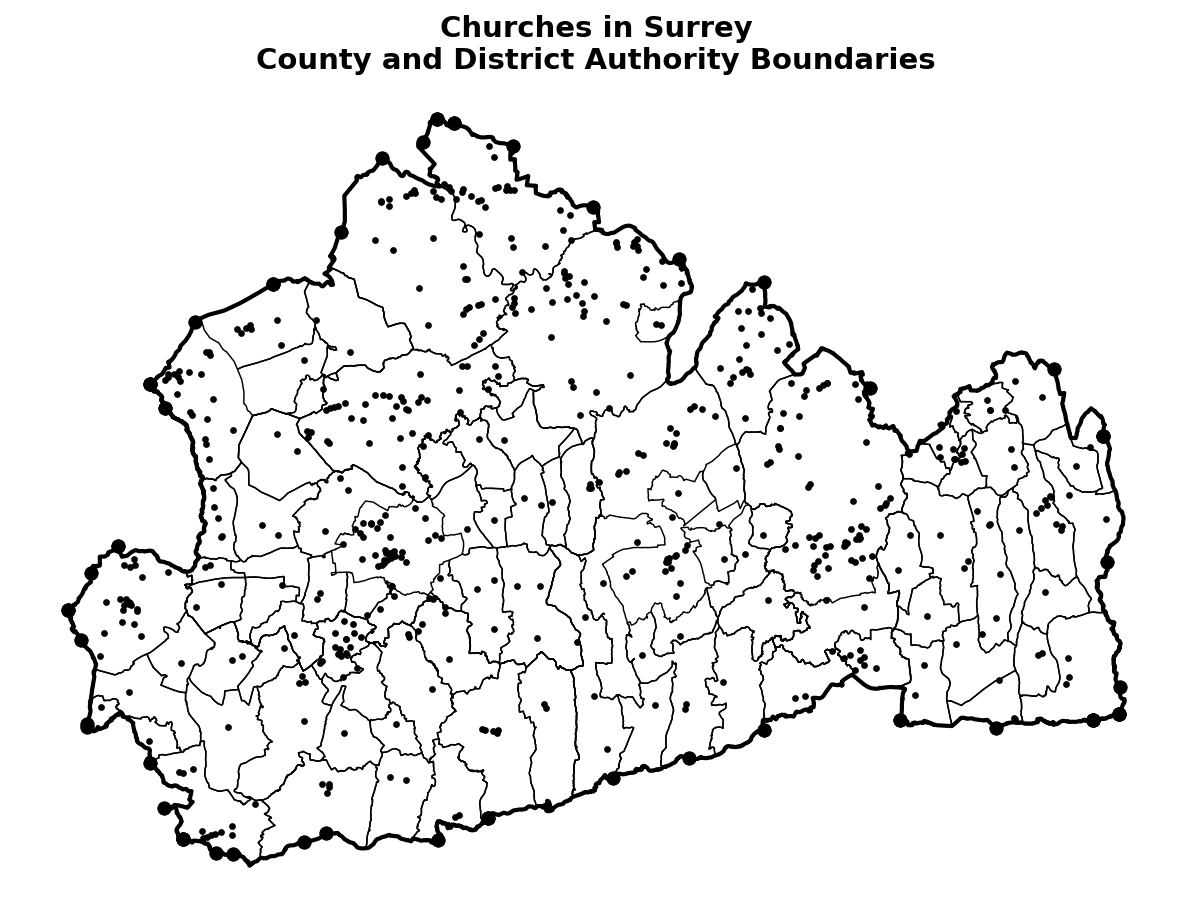

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

# County boundary (Surrey only)
surrey.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2
)

# District boundaries (clipped)
districts.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.7
)

# Churches as dots
ax.scatter(
    churches.x,
    churches.y,
    s=5,
    color="black"
)

# Clean line-art output
ax.set_axis_off()
ax.set_title(
    "Churches in Surrey\nCounty and District Authority Boundaries",
    fontsize=14,
    weight="bold"
)

plt.show()